In [28]:
from SoccerNet.Downloader import SoccerNetDownloader as SNdl
import os

In [31]:
mySNdl = SNdl(LocalDirectory="./")
mySNdl.downloadDataTask(task="mvfouls", split=["train","valid","test","challenge"], password="s0cc3rn3t")

In [32]:
list_splits = ["train", "valid", "test", "challenge"]

In [34]:
# Extract files from zipped folders
for split in list_splits:
    print(f"Unzipping {split}.zip ...")
    data_dir = "mvfouls/"
    subtask_data_dir = os.path.join(data_dir, split)
    subtask_data_dir.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

    zip_filename = Path(data_dir, f"{split}.zip")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(subtask_data_dir)
    print(f"... done unzipping {split}.zip")


    print(f"Remove {split}.zip ...")
    if os.path.exists(zip_filename):
        os.remove(zip_filename)
    else:
        print("The file does not exist")
    print(f"... {split}.zip has been removed")

Unzipping train.zip ...


AttributeError: 'str' object has no attribute 'mkdir'

In [42]:
import os
import json
import torch
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import torchvision.transforms as T
from PIL import Image

class SoccerNetMVFoulsDataset(Dataset):
    def __init__(self, annotation_path, num_frames=16, normalize=True):
        """
        annotation_path: path to train/test/valid annotations.json
        num_frames: number of frames to sample per clip
        normalize: apply ImageNet normalization if True
        """
        self.annotation_path = annotation_path
        self.num_frames = num_frames
        #self.resize_short = resize_short
        self.normalize = normalize

        # Transform for frames
        transform_list = []
        transform_list.append(T.ToTensor())  # HWC -> C,H,W, scales to [0,1]
        if normalize:
            transform_list.append(T.Normalize(mean=[0.45,0.45,0.45], std=[0.225,0.225,0.225]))
        self.frame_transform = T.Compose(transform_list)

        # Load annotations
        with open(annotation_path, "r") as f:
            data = json.load(f)

        self.samples = []
        self.labels = []

        # Map unique action classes to integers
        self.class_names = sorted(list({v["Action class"] for v in data["Actions"].values()}))
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}

        for _, action in data["Actions"].items():
            clips = [c["Url"] for c in action["Clips"]]
            self.samples.append(clips)
            self.labels.append(self.class_to_idx[action["Action class"]])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_urls = self.samples[idx]
        label = self.labels[idx]
        views = []
    
        # Root of dataset: SoccerNet/mvfouls
        dataset_root = os.path.dirname(os.path.dirname(self.annotation_path))
    
        for clip_path in clip_urls:
            # Full path to the mp4 file
            clip_path = clip_path.replace("Dataset/Train", "train") \
                                   .replace("Dataset/Test", "test") \
                                   .replace("Dataset/Valid", "valid")
            
            video_path = os.path.join(dataset_root, clip_path + ".mp4")
            print(video_path)
            if not os.path.exists(video_path):
                print("Missing clip file:", video_path)
                continue
    
            # Load video with Decord
            vr = VideoReader(video_path, ctx=cpu(0))
            total_frames = len(vr)
            # Sample frames uniformly
            indices = torch.linspace(0, total_frames - 1, self.num_frames).long()
            frames = vr.get_batch(indices.numpy()).asnumpy()  # T,H,W,C
            print(frames.shape)
    
            # Apply transforms to each frame
            processed_frames = [self.frame_transform(Image.fromarray(frame)) for frame in frames]
    
            # Stack frames: C,T,H,W
            frames_tensor = torch.stack(processed_frames, dim=0)
            views.append(frames_tensor)
    
        # Combine multi-view frames along channel dimension
        if len(views) == 0:
            raise RuntimeError(f"No valid clips found for sample {idx}")
    
        # Stack all views → (num_views, T, C, H, W)
        video_tensor = torch.stack(views, dim=0)
    
        return video_tensor, label
    



===== TRAIN SPLIT =====
Class Challenge (index 1): 383 samples
Class Tackling (index 9): 448 samples
Class Standing tackling (index 8): 1264 samples
Class High leg (index 5): 103 samples
Class Dive (index 2): 28 samples
Class Elbowing (index 4): 178 samples
Class  (index 0): 11 samples
Class Holding (index 6): 361 samples
Class Dont know (index 3): 52 samples
Class Pushing (index 7): 88 samples


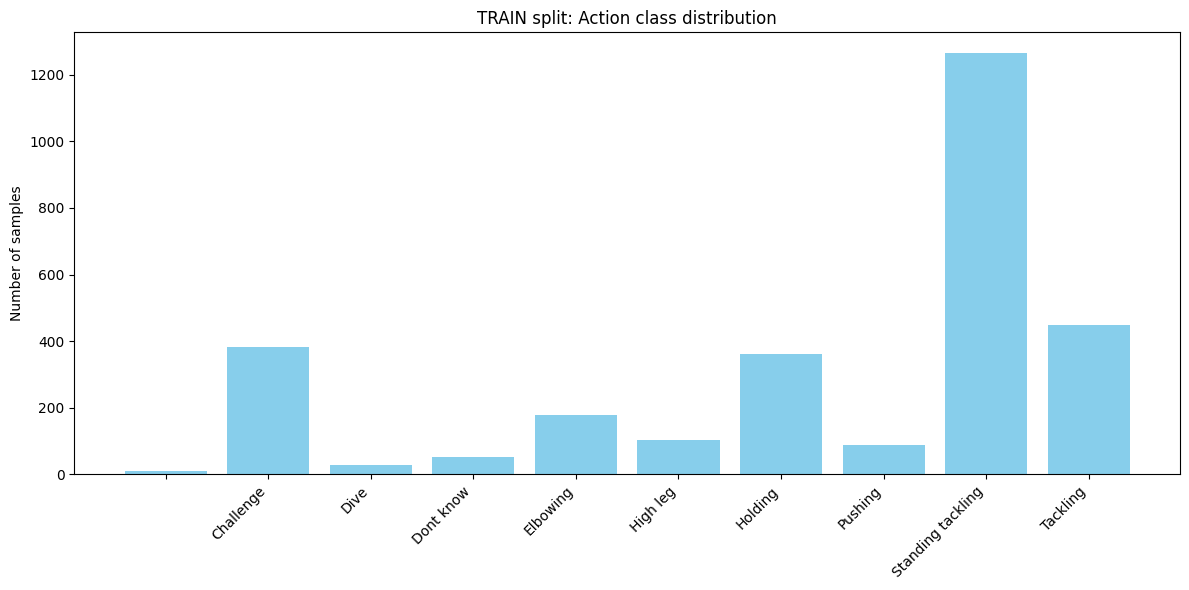


===== VALID SPLIT =====
Class Holding (index 6): 63 samples
Class Challenge (index 1): 42 samples
Class Elbowing (index 4): 19 samples
Class Standing tackling (index 8): 168 samples
Class Tackling (index 9): 80 samples
Class High leg (index 5): 18 samples
Class Pushing (index 7): 13 samples
Class Dont know (index 3): 5 samples
Class  (index 0): 2 samples
Class Dive (index 2): 1 samples


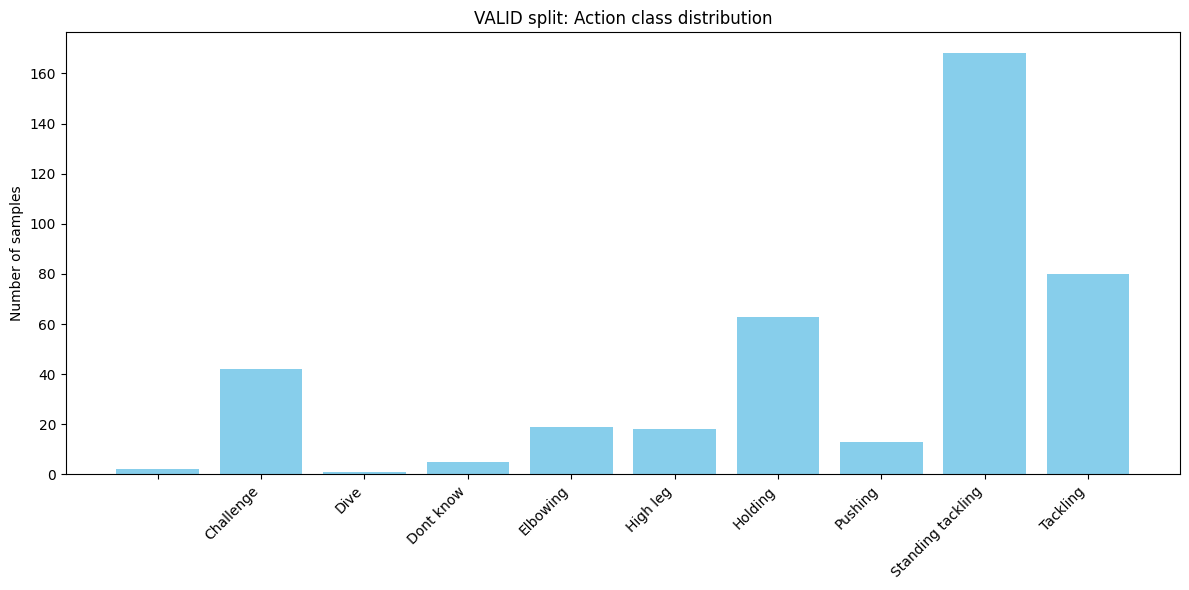


===== TEST SPLIT =====
Class Tackling (index 8): 48 samples
Class Elbowing (index 3): 21 samples
Class Standing tackling (index 7): 127 samples
Class Holding (index 5): 33 samples
Class Pushing (index 6): 7 samples
Class Challenge (index 1): 50 samples
Class Dive (index 2): 5 samples
Class High leg (index 4): 9 samples
Class  (index 0): 1 samples


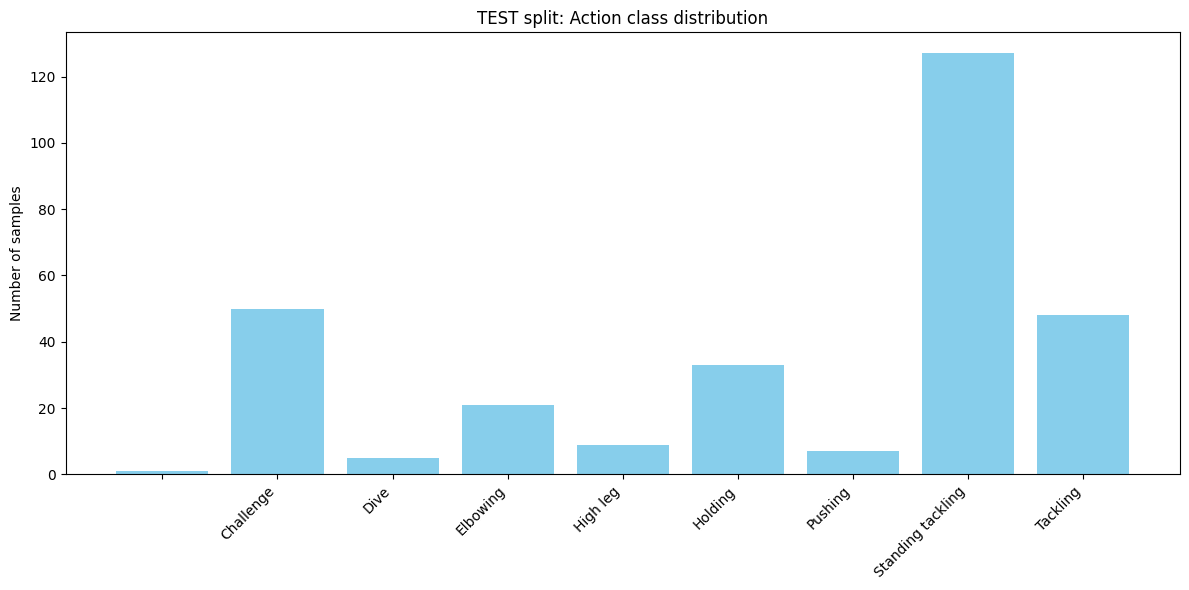

In [39]:
import matplotlib.pyplot as plt
from collections import Counter

splits = ["train", "valid", "test"]
dataset_root = "mvfouls"

for split in splits:
    annotation_path = f"{dataset_root}/{split}/annotations.json"
    dataset = SoccerNetMVFoulsDataset(annotation_path=annotation_path, num_frames=16)
    
    labels = [dataset.labels[i] for i in range(len(dataset))]
    label_counts = Counter(labels)

    class_names = dataset.class_names
    counts = [label_counts[i] for i in range(len(class_names))]

    # Print distribution
    print(f"\n===== {split.upper()} SPLIT =====")
    for idx, count in label_counts.items():
        print(f"Class {class_names[idx]} (index {idx}): {count} samples")

    # Plot distribution
    plt.figure(figsize=(12, 6))
    plt.bar(class_names, counts, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Number of samples")
    plt.title(f"{split.upper()} split: Action class distribution")
    plt.tight_layout()
    plt.show()


In [47]:
dataset = SoccerNetMVFoulsDataset(annotation_path="mvfouls/train/annotations.json", num_frames=16)
video_tensor, label = dataset[0]
print("Video tensor shape (V,T,C,H,W):", video_tensor.shape)
print("Label index:", label)

mvfouls/train/action_0/clip_0.mp4
(16, 224, 398, 3)
mvfouls/train/action_0/clip_1.mp4
(16, 224, 398, 3)
Video tensor shape (V,T,C,H,W): torch.Size([2, 16, 3, 224, 398])
Label index: 1


In [46]:
dataset = SoccerNetMVFoulsDataset(annotation_path="mvfouls/valid/annotations.json", num_frames=16)
video_tensor, label = dataset[3]
print("Video tensor shape (V,T,C,H,W):", video_tensor.shape)
print("Label index:", label)

mvfouls/valid/action_3/clip_0.mp4
(16, 224, 398, 3)
mvfouls/valid/action_3/clip_1.mp4
(16, 224, 398, 3)
mvfouls/valid/action_3/clip_2.mp4
(16, 224, 398, 3)
Video tensor shape (V,T,C,H,W): torch.Size([3, 16, 3, 224, 398])
Label index: 4
